# Credit Card Fraud Detection — Random Forest (Imbalanced Classification)

This notebook follows a clear and reproducible workflow:

1. **EDA**: understand the data, target distribution, and basic data checks.
2. **Pre-processing**: minimal cleaning (duplicates) and a stratified train/test split.
3. **Modeling**: Random Forest with cross-validation using metrics suited for imbalance (ROC-AUC and PR-AUC).
4. **Evaluation**: final training on the full training set and testing on unseen data.

> **Important note:** I tested two imbalance strategies (**SMOTE** vs **class_weight="balanced"**) and made a decision based on PR-AUC.


In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

np.random.seed(42)


## 1) EDA (Exploratory Data Analysis)

In this step I will:
- check missing values and duplicates
- inspect the target distribution (fraud vs non-fraud)
- visualize amount distribution (histogram + boxplot)
- review correlations (ranking + heatmap)

Goal: avoid training a model on broken data or obvious quality issues.


In [2]:
# Find the creditcard.csv
df = pd.read_csv("/kaggle/input/creditcardfraud/creditcard.csv")
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [3]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [4]:
# atribute information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
print("Missing values:\n", df.isna().sum())
print()
print("Duplicate rows:", df.duplicated().sum())


Missing values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Duplicate rows: 1081


In [6]:
df = df.drop_duplicates()
print("Shape after drop_duplicates:", df.shape)

Shape after drop_duplicates: (283726, 31)


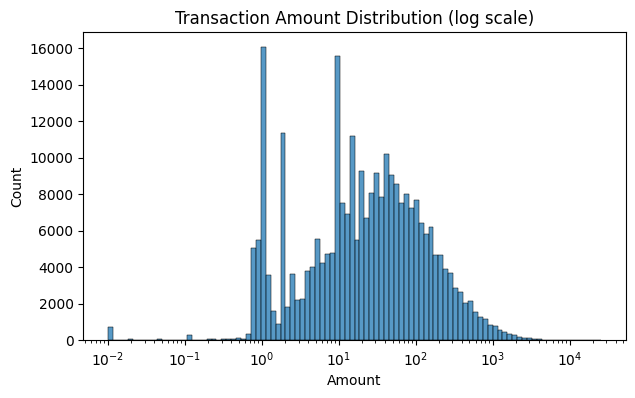

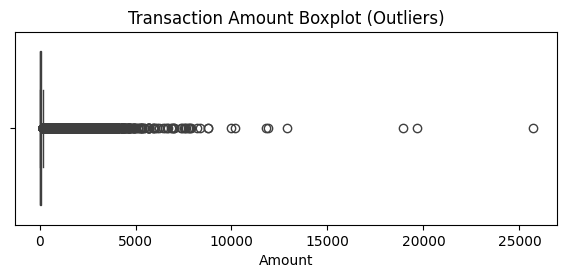

Class     1.000000
V11       0.149067
V4        0.129326
V2        0.084624
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
V28       0.009682
Amount    0.005777
V22       0.004887
V26       0.004265
V25       0.003202
V15      -0.003300
V13      -0.003897
V23      -0.006333
V24      -0.007210
Time     -0.012359
V6       -0.043915
V5       -0.087812
V9       -0.094021
V1       -0.094486
V18      -0.105340
V7       -0.172347
V3       -0.182322
V16      -0.187186
V10      -0.206971
V12      -0.250711
V14      -0.293375
V17      -0.313498
Name: Class, dtype: float64


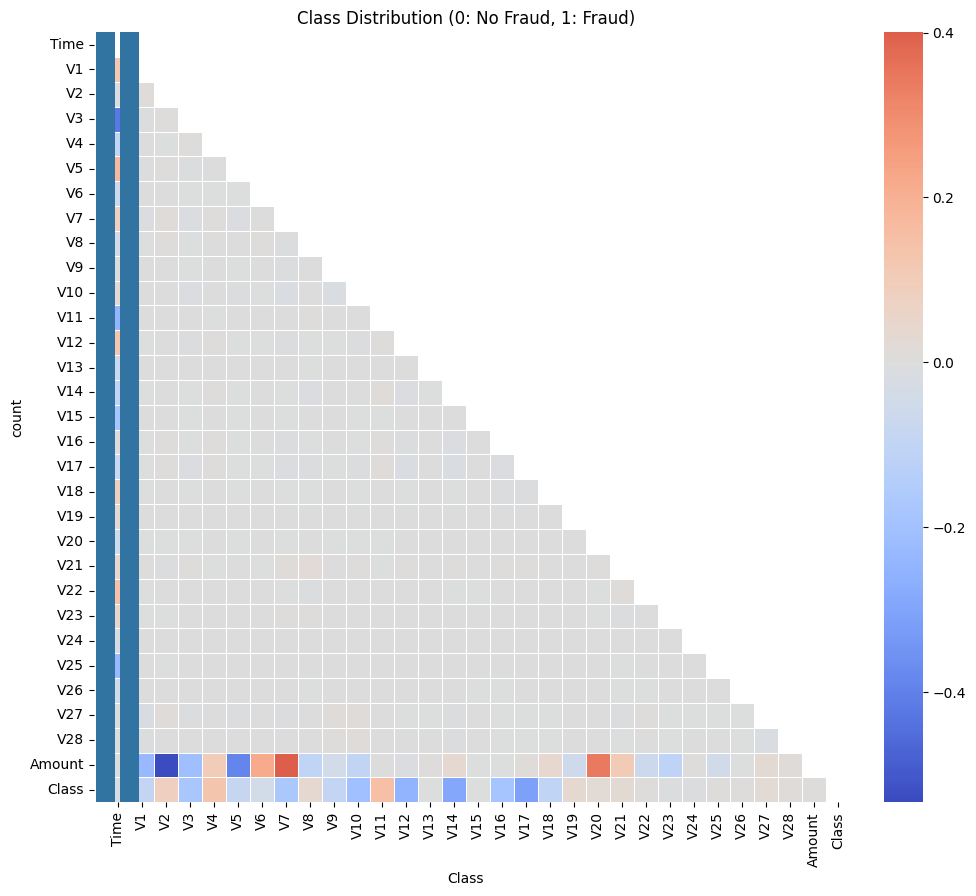

          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      283253.0   88.413575  250.379023  0.0  5.67  22.00   77.46  25691.16
1         473.0  123.871860  260.211041  0.0  1.00   9.82  105.89   2125.87


In [7]:
# Amount distribution + outliers
plt.figure(figsize=(7,4))
sns.histplot(df["Amount"], bins=100, log_scale=True)
plt.title("Transaction Amount Distribution (log scale)")
plt.show()

plt.figure(figsize=(7,2.5))
sns.boxplot(x=df["Amount"])
plt.title("Transaction Amount Boxplot (Outliers)")
plt.show()


print(df.corr()['Class'].sort_values(ascending=False))

#heatmap
mask = np.triu(np.ones_like(df.corr(), dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(
    df.corr(),
    mask=mask,
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

df['Class'].value_counts()
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0: No Fraud, 1: Fraud)')
plt.show()

print(df.groupby('Class')['Amount'].describe())

## 2) Pre-processing

Steps:
- define features (X) and target (y)


In [8]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=7, 
    stratify=y
    )

## 3) Modeling — CV-safe Pipeline (SMOTE vs Class Weights)

Because fraud detection is **highly imbalanced**, I focus on:
- **ROC-AUC** (overall ranking quality) 
- **PR-AUC (Average Precision)** (more informative for rare positive class) 

### Why a CV-safe pipeline?
When using SMOTE, it must be applied **only inside training folds**, not before CV, to avoid leakage.  
Using `imblearn.Pipeline` ensures samplers run during `fit`, not during `predict`. 

### Two strategies tested
1) **SMOTE + Random Forest**
2) **Random Forest with class_weight="balanced"** (no SMOTE) 

Final choice: I select the approach with **higher mean PR-AUC**.


In [9]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier

In [10]:


cv = StratifiedKFold(
    n_splits=5,      
    shuffle=True,    
    random_state=42  
)

scoring={           
        'roc_auc': 'roc_auc',               
        'pr_auc': 'average_precision'         
    }

pipeline_smote = Pipeline(steps=[
    
    ('smote', SMOTE(random_state=42, sampling_strategy=0.20)),
    ('model', RandomForestClassifier(
        n_estimators=200,   
        random_state=42,   
        n_jobs=-1,
    ))
])

scores_smote = cross_validate(
    pipeline_smote,          
    X_train,           
    y_train,          
    cv=cv,
    scoring=scoring,
    return_train_score=True  
)

    # Without SMOTE
pipeline_no_smote = Pipeline(steps=[
    ('model', RandomForestClassifier(
        n_estimators=200,   
        random_state=42,    
        n_jobs=-1,           
        class_weight="balanced"   
    ))
])

scores_no_smote = cross_validate(
    pipeline_no_smote,           
    X_train,           
    y_train,            
    cv=cv,
    scoring=scoring,
    return_train_score=True 
)

def summarize(scores_dict):
    return {
        "CV ROC-AUC mean": float(np.mean(scores_dict["test_roc_auc"])),
        "CV ROC-AUC std":  float(np.std(scores_dict["test_roc_auc"])),
        "CV PR-AUC mean":  float(np.mean(scores_dict["test_pr_auc"])),
        "CV PR-AUC std":   float(np.std(scores_dict["test_pr_auc"])),
    }

results = pd.DataFrame([
    {"Approach": "RandomForest + SMOTE", **summarize(scores_smote)},
    {"Approach": 'RandomForest + class_weight="balanced" (no SMOTE)', **summarize(scores_no_smote)},
]).sort_values("CV PR-AUC mean", ascending=False)

results.reset_index(drop=True, inplace=True)


results_rounded = results.copy()
for col in results_rounded.columns[1:]:
    results_rounded[col] = results_rounded[col].round(6)

results_rounded   

,Approach,CV ROC-AUC mean,CV ROC-AUC std,CV PR-AUC mean,CV PR-AUC std
0,RandomForest + SMOTE,0.968178,0.014294,0.822717,0.042379
1,"RandomForest + class_weight=""balanced"" (no SMOTE)",0.953690,0.014310,0.811131,0.030986


### Final decision

I tested both approaches.

After removing duplicate rows, the SMOTE pipeline achieved higher mean PR-AUC than the class-weight approach.  
Therefore, I selected **SMOTE (sampling_strategy=0.20)** as the final strategy, following a PR-AUC-driven decision rule.



## 4) Evaluation (Unseen Test Set)

Now I train the final model on the full training set and evaluate on the test set.
Metrics reported:
- Test ROC-AUC
- Test PR-AUC
- Classification report
- Confusion matrix


In [11]:
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

In [12]:
final_pipeline = pipeline_smote

final_pipeline.fit(X_train, y_train)

y_pred = final_pipeline.predict(X_test)
y_prob = final_pipeline.predict_proba(X_test)[:, 1]

print("---- Test Results (Unseen Test Set) ----")
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Test PR-AUC :", average_precision_score(y_test, y_prob))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

check_pred = pd.DataFrame({"Real": y_test, "Predicted": y_pred})
display(check_pred.head(10))


---- Test Results (Unseen Test Set) ----
Test ROC-AUC: 0.9712847256292414
Test PR-AUC : 0.8577046948726006

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     84976
           1       0.91      0.83      0.87       142

    accuracy                           1.00     85118
   macro avg       0.96      0.92      0.94     85118
weighted avg       1.00      1.00      1.00     85118



,Real,Predicted
123007,0,0
147501,0,0
199195,0,0
68094,0,0
142462,0,0
281993,0,0
136751,0,0
171936,0,0
222997,0,0
228275,0,0


In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

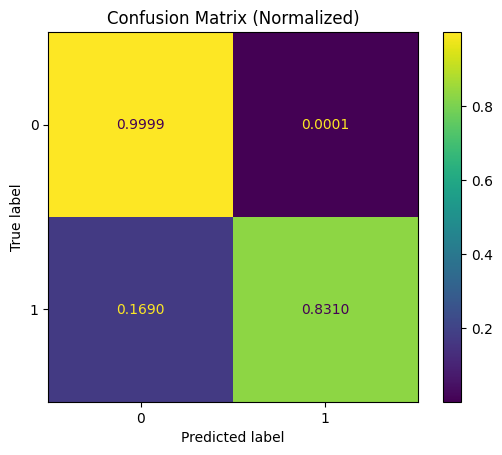

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, normalize="true", values_format=".4f"
)
plt.title("Confusion Matrix (Normalized)")
plt.show()


### Confusion Matrix (Normalized)
Using row-normalization (normalize="true"), the model achieves:
- **Non-fraud (Class 0): ~100% correctly classified**, with near-zero false positives.
- **Fraud (Class 1): ~0.83 recall**, meaning ~83% of fraud cases are detected, while ~17% remain false negatives.
This highlights a conservative model behavior, prioritizing low false-positive rates.


## Optional: LightGBM baseline (disabled by default)

This section runs only if `RUN_LGBM = True`.
It uses `scale_pos_weight` (common approach for imbalanced boosting models).


In [14]:
RUN_LGBM = False  # set True only if you want to run this section

if RUN_LGBM:
    from lightgbm import LGBMClassifier
    from sklearn.model_selection import cross_validate

    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    scale_pos_weight = neg / pos
    
    lgbm = LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight
    )
    
    scores_lgbm = cross_validate(
        lgbm, X_train, y_train, cv=cv,
        scoring={"roc_auc": "roc_auc", "pr_auc": "average_precision"},
        return_train_score=False
    )
    
    print("LGBM CV ROC-AUC mean:", scores_lgbm["test_roc_auc"].mean())
    print("LGBM CV PR-AUC mean :", scores_lgbm["test_pr_auc"].mean())
